In [1]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import glob
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.metrics import root_mean_squared_error
from sklearn.metrics import mean_squared_error
import os
import pandas as pd

In [2]:
ds = xr.open_dataset("/home/sallen/MEOPAR/grid/weights-gem2.5-gemlam_201702_pre22sep11.nc")
ds

<xarray.Dataset> Size: 24MB
Dimensions:  (lat: 266, lon: 256, y: 898, x: 398)
Dimensions without coordinates: lat, lon, y, x
Data variables:
    nav_lat  (lat, lon) float64 545kB ...
    nav_lon  (lat, lon) float64 545kB ...
    src01    (y, x) int64 3MB ...
    wgt01    (y, x) float64 3MB ...
    src02    (y, x) int64 3MB ...
    wgt02    (y, x) float64 3MB ...
    src03    (y, x) int64 3MB ...
    wgt03    (y, x) float64 3MB ...
    src04    (y, x) int64 3MB ...
    wgt04    (y, x) float64 3MB ...
Attributes:
    Conventions:  CF-1.6
    title:        SalishSeaCast NEMO GEMLAM 2.5km Experimental pre-22-Sep-201...
    institution:  Dept of Earth, Ocean & Atmospheric Sciences, University of ...
    source:       NEMO_EastCoast/NEMO_Preparation/4_weights_ATMOS/get_weight_...
    references:   https://salishsea-meopar-docs.readthedocs.io/en/latest/code...
    history:      [2022-03-21 12:04:51] Converted to netCDF4 zlib=True datase...
    comment:

In [3]:
ds["wgt01"]

<xarray.DataArray 'wgt01' (y: 898, x: 398)> Size: 3MB
[357404 values with dtype=float64]
Dimensions without coordinates: y, x
Attributes:
    units:        1
    long_name:    SalishSeaCast NEMO Grid Weights for src01
    valid_range:  [0.24970044 0.99925254]

In [4]:
ds["src01"]

<xarray.DataArray 'src01' (y: 898, x: 398)> Size: 3MB
[357404 values with dtype=int64]
Dimensions without coordinates: y, x
Attributes:
    units:        1
    long_name:    GEMLAM 2.5km Experimental pre-22-Sep-2011 grid Grid Index 1...
    valid_range:  [ 8322 56968]

In [5]:
ds["src01"].values[0]

array([ 8322,  8322,  8322,  8322,  8323,  8323,  8323,  8323,  8323,
        8323,  8324,  8324,  8324,  8324,  8324,  8325,  8581,  8581,
        8581,  8581,  8581,  8582,  8582,  8582,  8582,  8582,  8582,
        8583,  8583,  8583,  8583,  8583,  8583,  8584,  8840,  8840,
        8840,  8840,  8841,  8841,  8841,  8841,  8841,  8841,  8842,
        8842,  8842,  8842,  8842,  8842,  8843,  8843,  9099,  9099,
        9099,  9099,  9100,  9100,  9100,  9100,  9100,  9100,  9101,
        9101,  9101,  9101,  9101,  9102,  9102,  9358,  9358,  9358,
        9358,  9359,  9359,  9359,  9359,  9359,  9359,  9360,  9360,
        9360,  9360,  9360,  9360,  9361,  9361,  9617,  9617,  9617,
        9618,  9618,  9618,  9618,  9618,  9618,  9619,  9619,  9619,
        9619,  9619,  9619,  9620,  9620,  9876,  9876,  9876,  9876,
        9877,  9877,  9877,  9877,  9877,  9877,  9878,  9878,  9878,
        9878,  9878,  9879,  9879,  9879, 10135, 10135, 10135, 10136,
       10136, 10136,

In [6]:
ds["wgt01"].values[0]

array([0.57931773, 0.60962881, 0.53230878, 0.43551695, 0.52865759,
       0.7203064 , 0.93154302, 0.84228053, 0.6332274 , 0.44380114,
       0.54156626, 0.63585281, 0.69507396, 0.5275703 , 0.37937312,
       0.28357132, 0.36741447, 0.50721647, 0.60216316, 0.53592221,
       0.45007007, 0.45842242, 0.63938471, 0.8399837 , 0.88368901,
       0.71534993, 0.51537548, 0.52445764, 0.62922529, 0.71436819,
       0.60033253, 0.44147746, 0.30205698, 0.33827663, 0.44073525,
       0.58978981, 0.53890071, 0.46372571, 0.39262712, 0.56342509,
       0.7536509 , 0.89848161, 0.78217512, 0.59186914, 0.49832769,
       0.61283542, 0.70786876, 0.6766212 , 0.50761984, 0.35819726,
       0.33173482, 0.38543373, 0.51869253, 0.54165565, 0.47681571,
       0.39238795, 0.49102076, 0.67125676, 0.87088627, 0.80801143,
       0.67429345, 0.47370512, 0.587771  , 0.69210344, 0.75708454,
       0.57826499, 0.41908923, 0.3172027 , 0.38039243, 0.45326502,
       0.54495927, 0.48994425, 0.41541333, 0.42318694, 0.59371

In [7]:
years = [2008, 2009, 2010, 2011, 2012]
output_dir = "/ocean/dtaneja/MOAD/analysis-dishika/notebooks/data"
os.makedirs(output_dir, exist_ok=True)

hrdps_processed_files = []
for year in years:
    file = f"{output_dir}/HRDPS_{year}_tair_3h_with_latlon.nc"
    hrdps_processed_files.append(file)
ds_hrdps = xr.open_mfdataset(hrdps_processed_files,combine="by_coords")
ds_hrdps = ds_hrdps.sortby("time_counter")
print(ds_hrdps)

/tmp/ipykernel_2079073/1211250413.py:9: FutureWarning: In a future version of xarray the default value for coords will change from coords='different' to coords='minimal'. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set coords explicitly.
  ds_hrdps = xr.open_mfdataset(hrdps_processed_files,combine="by_coords")


<xarray.Dataset> Size: 12GB
Dimensions:       (time_counter: 14592, y: 266, x: 256)
Coordinates:
  * time_counter  (time_counter) datetime64[ns] 117kB 2008-01-01 ... 2012-12-...
    nav_lat       (time_counter, y, x) float32 4GB 45.61 45.62 ... 52.37 52.37
    nav_lon       (time_counter, y, x) float32 4GB 232.7 232.7 ... 239.6 239.7
Dimensions without coordinates: y, x
Data variables:
    tair          (time_counter, y, x) float32 4GB dask.array<chunksize=(2912, 266, 256), meta=np.ndarray>


In [8]:
# Training: 2009, 2010, and 2011
ds_hrdps_train = ds_hrdps.sel(time_counter=slice("2009-01-01", "2011-12-31"))
# Validation: 2008
ds_hrdps_val = ds_hrdps.sel(time_counter=slice("2008-01-01", "2008-12-31"))
# Testing: 2012
ds_hrdps_test = ds_hrdps.sel(time_counter=slice("2012-01-01", "2012-12-31"))
print("HRDPS Training:")
print(ds_hrdps_train.time_counter.values[0],"to",ds_hrdps_train.time_counter.values[-1])
print("HRDPS Validation:")
print(ds_hrdps_val.time_counter.values[0],"to",ds_hrdps_val.time_counter.values[-1])
print("HRDPS Testing:")
print(ds_hrdps_test.time_counter.values[0],"to",ds_hrdps_test.time_counter.values[-1])

HRDPS Training:
2009-01-01T00:00:00.000000000 to 2011-12-31T21:00:00.000000000
HRDPS Validation:
2008-01-01T00:00:00.000000000 to 2008-12-31T21:00:00.000000000
HRDPS Testing:
2012-01-01T00:00:00.000000000 to 2012-12-31T21:00:00.000000000


In [9]:
canrcm_years = [2008, 2009, 2010, 2011, 2012]
canrcm_tas_files = []
for year in canrcm_years:
    matches = sorted(glob.glob(f"/results/forcing/CanRCM5/"f"*_{year}01_{year}12_3h_tas.nc"))
    canrcm_tas_files.append(matches[0])

print("CanRCM temperature files:")
for file in canrcm_tas_files:
    print(file)

CanRCM temperature files:
/results/forcing/CanRCM5/sc_nam22r55lkn3-bc07_200801_200812_3h_tas.nc
/results/forcing/CanRCM5/sc_nam22r55lkn3-bc07_200901_200912_3h_tas.nc
/results/forcing/CanRCM5/sc_nam22r55lkn3-bc07_201001_201012_3h_tas.nc
/results/forcing/CanRCM5/sc_nam22r55lkn3-bc07_201101_201112_3h_tas.nc
/results/forcing/CanRCM5/sc_nam22r55lkn3-bc07_201201_201212_3h_tas.nc


In [10]:
from datetime import timedelta
ds_canrcm = xr.open_mfdataset(canrcm_tas_files,combine="by_coords")
ds_canrcm = ds_canrcm.sortby("time")
ds_canrcm = ds_canrcm.assign_coords(time=ds_canrcm.time.values - timedelta(hours=3))
print(ds_canrcm)

<xarray.Dataset> Size: 7GB
Dimensions:       (time: 14600, bnds: 2, rlat: 320, rlon: 360)
Coordinates:
  * time          (time) object 117kB 2008-01-01 00:00:00 ... 2012-12-31 21:0...
  * rlat          (rlat) float64 3kB -35.11 -34.89 -34.67 ... 34.63 34.85 35.07
  * rlon          (rlon) float64 3kB -39.27 -39.05 -38.83 ... 39.27 39.49 39.71
    lon           (rlat, rlon) float64 922kB dask.array<chunksize=(320, 360), meta=np.ndarray>
    lat           (rlat, rlon) float64 922kB dask.array<chunksize=(320, 360), meta=np.ndarray>
Dimensions without coordinates: bnds
Data variables:
    time_bnds     (time, bnds) object 234kB dask.array<chunksize=(2920, 2), meta=np.ndarray>
    rotated_pole  (time) |S1 15kB b'' b'' b'' b'' b'' ... b'' b'' b'' b'' b''
    tas           (time, rlat, rlon) float32 7GB dask.array<chunksize=(2920, 320, 360), meta=np.ndarray>
Attributes: (12/17)
    title:                          CanRCM4 model output prepared for CORDEX ...
    institution:                    

/tmp/ipykernel_2079073/3930337657.py:2: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  ds_canrcm = xr.open_mfdataset(canrcm_tas_files,combine="by_coords")


In [11]:
lat_hr = ds_hrdps["nav_lat"]
lon_hr = ds_hrdps["nav_lon"]
lon_hr_normalized = ((lon_hr + 180) % 360) - 180
lat_min = float(lat_hr.min())
lat_max = float(lat_hr.max())
lon_min = float(lon_hr_normalized.min())
lon_max = float(lon_hr_normalized.max())
print("HRDPS latitude range:")
print(lat_min, "to", lat_max)
print("HRDPS longitude range:")
print(lon_min, "to", lon_max)

HRDPS latitude range:
45.52116012573242 to 52.4603157043457
HRDPS longitude range:
-129.47222900390625 to -119.20327758789062


In [12]:
lat_lr = ds_canrcm["lat"]
lon_lr = ds_canrcm["lon"]
lon_lr_normalized = ((lon_lr + 180) % 360) - 180
mask_lr = ((lat_lr >= lat_min) &(lat_lr <= lat_max) &(lon_lr_normalized >= lon_min) &(lon_lr_normalized <= lon_max))
i_idx, j_idx = np.where(mask_lr.values)
i_min = i_idx.min()
i_max = i_idx.max()
j_min = j_idx.min()
j_max = j_idx.max()
print("CanRCM grid indices:")
print("rlat:", i_min, "to", i_max)
print("rlon:", j_min, "to", j_max)

CanRCM grid indices:
rlat: 161 to 200
rlon: 79 to 117


In [13]:
ds_canrcm_cut = (ds_canrcm[["tas"]].isel(rlat=slice(i_min, i_max + 1),rlon=slice(j_min, j_max + 1)))
print(ds_canrcm_cut)

<xarray.Dataset> Size: 91MB
Dimensions:  (time: 14600, rlat: 40, rlon: 39)
Coordinates:
  * time     (time) object 117kB 2008-01-01 00:00:00 ... 2012-12-31 21:00:00
  * rlat     (rlat) float64 320B 0.31 0.53 0.75 0.97 ... 8.23 8.45 8.67 8.89
  * rlon     (rlon) float64 312B -21.89 -21.67 -21.45 ... -13.97 -13.75 -13.53
    lon      (rlat, rlon) float64 12kB dask.array<chunksize=(40, 39), meta=np.ndarray>
    lat      (rlat, rlon) float64 12kB dask.array<chunksize=(40, 39), meta=np.ndarray>
Data variables:
    tas      (time, rlat, rlon) float32 91MB dask.array<chunksize=(2920, 40, 39), meta=np.ndarray>
Attributes: (12/17)
    title:                          CanRCM4 model output prepared for CORDEX ...
    institution:                    CCCma (Canadian Centre for Climate Modell...
    institute_id:                   CCCma
    driving_experiment:             , , r1i1p1
    driving_model_ensemble_member:  r1i1p1
    realization:                    1
    ...                             ..

In [14]:
# Training: 2009, 2010, and 2011
ds_canrcm_train = ds_canrcm_cut.sel(time=slice("2009-01-01", "2011-12-31"))
# Validation: 2008
ds_canrcm_val = ds_canrcm_cut.sel(time=slice("2008-01-01", "2008-12-31"))
# Testing: 2012
ds_canrcm_test = ds_canrcm_cut.sel(time=slice("2012-01-01", "2012-12-31"))
print("CanRCM Training:")
print(ds_canrcm_train.time.values[0], "to", ds_canrcm_train.time.values[-1])
print("CanRCM Validation:")
print(ds_canrcm_val.time.values[0], "to", ds_canrcm_val.time.values[-1])
print("CanRCM Testing:")
print(ds_canrcm_test.time.values[0], "to", ds_canrcm_test.time.values[-1])

CanRCM Training:
2009-01-01 00:00:00 to 2011-12-31 21:00:00
CanRCM Validation:
2008-01-01 00:00:00 to 2008-12-31 21:00:00
CanRCM Testing:
2012-01-01 00:00:00 to 2012-12-31 21:00:00


In [15]:
def time_to_string(value):
    if isinstance(value, np.datetime64):
        return np.datetime_as_string(value,unit="s").replace("T", " ")
    if hasattr(value, "strftime"):
        return value.strftime("%Y-%m-%d %H:%M:%S")
    raise TypeError(f"Unsupported time type: {type(value)}")

def align_time_pair(ds_canrcm_split, ds_hrdps_split):
    canrcm_times = []
    for t in ds_canrcm_split.time.values:
        canrcm_times.append(time_to_string(t))
    canrcm_times = np.array(canrcm_times)
    
    hrdps_times = []
    for t in ds_hrdps_split.time_counter.values:
        hrdps_times.append(time_to_string(t))
    hrdps_times = np.array(hrdps_times)
    
    common_times, canrcm_idx, hrdps_idx = np.intersect1d(canrcm_times,hrdps_times,return_indices=True)
    ds_canrcm_aligned = ds_canrcm_split.isel(time=canrcm_idx)
    ds_hrdps_aligned = ds_hrdps_split.isel(time_counter=hrdps_idx)
    
    return ds_canrcm_aligned, ds_hrdps_aligned

In [16]:
ds_canrcm_train, ds_hrdps_train = align_time_pair(ds_canrcm_train,ds_hrdps_train)
ds_canrcm_val, ds_hrdps_val = align_time_pair(ds_canrcm_val,ds_hrdps_val)
ds_canrcm_test, ds_hrdps_test = align_time_pair(ds_canrcm_test,ds_hrdps_test)
print("Training:")
print("CanRCM:", len(ds_canrcm_train.time))
print("HRDPS: ", len(ds_hrdps_train.time_counter))
print("Validation:")
print("CanRCM:", len(ds_canrcm_val.time))
print("HRDPS: ", len(ds_hrdps_val.time_counter))
print("Testing:")
print("CanRCM:", len(ds_canrcm_test.time))
print("HRDPS: ", len(ds_hrdps_test.time_counter))

Training:
CanRCM: 8760
HRDPS:  8760
Validation:
CanRCM: 2904
HRDPS:  2904
Testing:
CanRCM: 2912
HRDPS:  2912


In [17]:
X_canrcm_train = ds_canrcm_train["tas"].values.reshape(len(ds_canrcm_train.time),-1).astype(np.float32)
X_hrdps_train = ds_hrdps_train["tair"].values.reshape(len(ds_hrdps_train.time_counter),-1).astype(np.float32)
print("CanRCM training matrix shape:", X_canrcm_train.shape)
print("HRDPS training matrix shape:", X_hrdps_train.shape)
print("Missing CanRCM values:", np.isnan(X_canrcm_train).sum())
print("Missing HRDPS values:", np.isnan(X_hrdps_train).sum())

CanRCM training matrix shape: (8760, 1560)
HRDPS training matrix shape: (8760, 68096)
Missing CanRCM values: 0
Missing HRDPS values: 5175296


In [18]:
X_hrdps_train_raw = (ds_hrdps_train["tair"].squeeze(drop=True).values.reshape(len(ds_hrdps_train.time_counter), -1).astype(np.float32))
all_nan_times = np.isnan(X_hrdps_train_raw).all(axis=1)

In [19]:
keep_time = ~all_nan_times
ds_hrdps_train = ds_hrdps_train.isel(time_counter=keep_time)
ds_canrcm_train = ds_canrcm_train.isel(time=keep_time)

In [20]:
X_hrdps_train = (ds_hrdps_train["tair"].squeeze(drop=True).values.reshape(len(ds_hrdps_train.time_counter), -1).astype(np.float32))
X_canrcm_train = (ds_canrcm_train["tas"].squeeze(drop=True).values.reshape(len(ds_canrcm_train.time), -1).astype(np.float32))

In [21]:
valid_hrdps_cells = np.isfinite(X_hrdps_train).all(axis=0)
X_hrdps_train = X_hrdps_train[:, valid_hrdps_cells]

In [22]:
print("CanRCM matrix shape:", X_canrcm_train.shape)
print("HRDPS matrix shape: ", X_hrdps_train.shape)

CanRCM matrix shape: (8684, 1560)
HRDPS matrix shape:  (8684, 68096)


In [23]:
n_hrdps_final = 28
n_canrcm_final = 30

In [24]:
# Fit PCA
pca_canrcm = PCA()
pca_canrcm.fit(X_canrcm_train)
pca_hrdps = PCA()
pca_hrdps.fit(X_hrdps_train)

,"n_components n_components: int, float or 'mle', default=NoneNumber of components to keep.if n_components is not set all components are kept:: n_components == min(n_samples, n_features)If ``n_components == 'mle'`` and ``svd_solver == 'full'``, Minka'sMLE is used to guess the dimension. Use of ``n_components == 'mle'``will interpret ``svd_solver == 'auto'`` as ``svd_solver == 'full'``.If ``0 < n_components < 1`` and ``svd_solver == 'full'``, select thenumber of components such that the amount of variance that needs to beexplained is greater than the percentage specified by n_components.If ``svd_solver == 'arpack'``, the number of components must bestrictly less than the minimum of n_features and n_samples.Hence, the None case results in:: n_components == min(n_samples, n_features) - 1",None
,"copy copy: bool, default=TrueIf False, data passed to fit are overwritten and runningfit(X).transform(X) will not yield the expected results,use fit_transform(X) instead.",True
,"whiten whiten: bool, default=FalseWhen True (False by default) the `components_` vectors are multipliedby the square root of n_samples and then divided by the singular valuesto ensure uncorrelated outputs with unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimeimprove the predictive accuracy of the downstream estimators bymaking their data respect some hard-wired assumptions.",False
,"svd_solver svd_solver: {'auto', 'full', 'covariance_eigh', 'arpack', 'randomized'}, default='auto'""auto"" : The solver is selected by a default 'auto' policy is based on `X.shape` and `n_components`: if the input data has fewer than 1000 features and more than 10 times as many samples, then the ""covariance_eigh"" solver is used. Otherwise, if the input data is larger than 500x500 and the number of components to extract is lower than 80% of the smallest dimension of the data, then the more efficient ""randomized"" method is selected. Otherwise the exact ""full"" SVD is computed and optionally truncated afterwards.""full"" : Run exact full SVD calling the standard LAPACK solver via `scipy.linalg.svd` and select the components by postprocessing""covariance_eigh"" : Precompute the covariance matrix (on centered data), run a classical eigenvalue decomposition on the covariance matrix typically using LAPACK and select the components by postprocessing. This solver is very efficient for n_samples >> n_features and small n_features. It is, however, not tractable otherwise for large n_features (large memory footprint required to materialize the covariance matrix). Also note that compared to the ""full"" solver, this solver effectively doubles the condition number and is therefore less numerical stable (e.g. on input data with a large range of singular values).""arpack"" : Run SVD truncated to `n_components` calling ARPACK solver via `scipy.sparse.linalg.svds`. It requires strictly `0 < n_components < min(X.shape)`""randomized"" : Run randomized SVD by the method of Halko et al... versionadded:: 0.18.0.. versionchanged:: 1.5 Added the 'covariance_eigh' solver.",'auto'
,"tol tol: float, default=0.0Tolerance for singular values computed by svd_solver == 'arpack'.Must be of range [0.0, infinity)... versionadded:: 0.18.0",0.0
,"iterated_power iterated_power: int or 'auto', default='auto'Number of iterations for the power method computed bysvd_solver == 'randomized'.Must be of range [0, infinity)... versionadded:: 0.18.0",'auto'
,"n_oversamples n_oversamples: int, default=10This parameter is only relevant when `svd_solver=""randomized""`.It corresponds to the additional number of random vectors to sample therange of `X` so as to ensure proper conditioning. See:func:`~sklearn.utils.extmath.randomized_svd` for more details... versionadded:: 1.1",10
,"power_iteration_normalizer power_iteration_normalizer: {'auto', 'QR', 'LU', 'none'}, default='auto'Power iteration normalizer for randomized S

In [25]:
canrcm_train_scores = (pca_canrcm.transform(X_canrcm_train)[:, :n_canrcm_final])
hrdps_train_scores = (pca_hrdps.transform(X_hrdps_train)[:, :n_hrdps_final])
regression_model = LinearRegression()
regression_model.fit(canrcm_train_scores,hrdps_train_scores)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float32](28, 30)","[[ 6.21, 1.71,-0.83,...,-1.49,-0.49,-1.18], [-0.04, 3.62, 4.62,..., 1. , 3.71,-1.29], [ 0.03,-2.58, 2.09,...,-2.46,-0.11,-1.67], ..., [-0. ,-0. ,-0.02,..., 0.25,-0.08, 0.04], [ 0. ,-0.02, 0.03,..., 0.14,-0.16,-0.62], [ 0. ,-0.02,-0. ,...,-0.14, 0.25,-0.1 ]]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.","ndarray[float32](28,)","[ 0.05,-0.05,-0. ,..., 0.01, 0. ,-0.01]"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,30
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,30
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float32](30,)","[25043.18, 4853.64, 4556.86,..., 532.48, 511.75, 504.35]"


In [26]:
X_canrcm_val_raw = (ds_canrcm_val["tas"].squeeze(drop=True).values.reshape(len(ds_canrcm_val.time), -1).astype(np.float32))
X_hrdps_val_raw = (ds_hrdps_val["tair"].squeeze(drop=True).values.reshape(len(ds_hrdps_val.time_counter), -1).astype(np.float32))
valid_val_times = (np.isfinite(X_canrcm_val_raw).all(axis=1)& np.isfinite(X_hrdps_val_raw[:, valid_hrdps_cells]).all(axis=1))
X_canrcm_val = X_canrcm_val_raw[valid_val_times]
X_hrdps_val_full = X_hrdps_val_raw[valid_val_times]
X_hrdps_val = X_hrdps_val_full[:, valid_hrdps_cells]

val_times = ds_hrdps_val.time_counter.values[valid_val_times]

print("CanRCM validation matrix:", X_canrcm_val.shape)
print("HRDPS validation matrix:", X_hrdps_val.shape)
print("Validation timestamps kept:", len(val_times))

CanRCM validation matrix: (2842, 1560)
HRDPS validation matrix: (2842, 68096)
Validation timestamps kept: 2842


In [27]:
canrcm_val_scores = (pca_canrcm.transform(X_canrcm_val)[:, :n_canrcm_final])
hrdps_val_scores_actual = (pca_hrdps.transform(X_hrdps_val)[:, :n_hrdps_final])
hrdps_val_scores_pred = regression_model.predict(canrcm_val_scores)

In [28]:
val_r2_average = r2_score(hrdps_val_scores_actual,hrdps_val_scores_pred,multioutput="uniform_average")
val_r2_weighted = r2_score(hrdps_val_scores_actual,hrdps_val_scores_pred,multioutput="variance_weighted")
val_r2_per_pc = r2_score(hrdps_val_scores_actual,hrdps_val_scores_pred,multioutput="raw_values")
print("Validation average R²:", val_r2_average)
print("Validation variance-weighted R²:", val_r2_weighted)
print("Validation R² for each HRDPS PC:")
print(val_r2_per_pc)

Validation average R²: 0.2917196750640869
Validation variance-weighted R²: 0.952333927154541
Validation R² for each HRDPS PC:
[ 0.9831632   0.8549121   0.6774999   0.7808743   0.54758644 -0.31669843
  0.18074775  0.40567076  0.42206955  0.41811103  0.35434777  0.22284561
  0.27474928  0.27833027  0.15414804  0.18339926  0.2299853   0.20051414
  0.26878273  0.13215566  0.24652869  0.10068691  0.155743    0.11813796
  0.0918709   0.0942468   0.08542907  0.02231312]


In [29]:
hrdps_val_scores_pred_full = np.zeros((len(hrdps_val_scores_pred), pca_hrdps.n_components_),dtype=np.float32)
hrdps_val_scores_pred_full[:, :n_hrdps_final] = hrdps_val_scores_pred
X_hrdps_val_pred = pca_hrdps.inverse_transform(hrdps_val_scores_pred_full).astype(np.float32)
print("Reconstructed predicted HRDPS matrix:", X_hrdps_val_pred.shape)

Reconstructed predicted HRDPS matrix: (2842, 68096)


In [30]:
X_hrdps_val_pred_full = np.full(shape=(len(X_hrdps_val_pred), len(valid_hrdps_cells)),fill_value=np.nan,dtype=np.float32)
X_hrdps_val_pred_full[:, valid_hrdps_cells] = X_hrdps_val_pred
print("Full reconstructed HRDPS matrix:", X_hrdps_val_pred_full.shape)

Full reconstructed HRDPS matrix: (2842, 68096)


In [31]:
ds_weights = xr.open_dataset("/home/sallen/MEOPAR/grid/weights-gem2.5-gemlam_201702_pre22sep11.nc")

In [32]:
print("Weights-file atmospheric grid:", ds_weights["nav_lat"].shape)
print("Expected HRDPS grid:", ds_hrdps_val["tair"].squeeze(drop=True).shape[1:])

Weights-file atmospheric grid: (266, 256)
Expected HRDPS grid: (266, 256)


In [33]:
src = np.stack([ds_weights["src01"].values,ds_weights["src02"].values,ds_weights["src03"].values,ds_weights["src04"].values,]).astype(np.int64)
wgt = np.stack([ds_weights["wgt01"].values,ds_weights["wgt02"].values,ds_weights["wgt03"].values,ds_weights["wgt04"].values,]).astype(np.float32)

In [34]:
src = src - 1

In [35]:
n_hrdps_cells = 266 * 256
print("Source-index array shape:", src.shape)
print("Weight array shape:", wgt.shape)
print("Smallest source index:", src.min())
print("Largest source index:", src.max())
print("Weight-sum range:", wgt.sum(axis=0).min(), "to", wgt.sum(axis=0).max())
assert src.min() >= 0
assert src.max() < n_hrdps_cells

Source-index array shape: (4, 898, 398)
Weight array shape: (4, 898, 398)
Smallest source index: 8064
Largest source index: 57223
Weight-sum range: 0.9999999 to 1.0000001


In [36]:
def interpolate_hrdps_to_salishsea(hrdps_flat_field, src, wgt):
    return np.sum(wgt * hrdps_flat_field[src],axis=0)

In [37]:
time_index = 0
salishsea_actual = interpolate_hrdps_to_salishsea(X_hrdps_val_full[time_index],src,wgt)
salishsea_pred = interpolate_hrdps_to_salishsea(X_hrdps_val_pred_full[time_index],src,wgt)
print("Actual SalishSeaCast-grid field:", salishsea_actual.shape)
print("Predicted SalishSeaCast-grid field:", salishsea_pred.shape)
print("Timestamp:", val_times[time_index])

Actual SalishSeaCast-grid field: (898, 398)
Predicted SalishSeaCast-grid field: (898, 398)
Timestamp: 2008-01-01T00:00:00.000000000


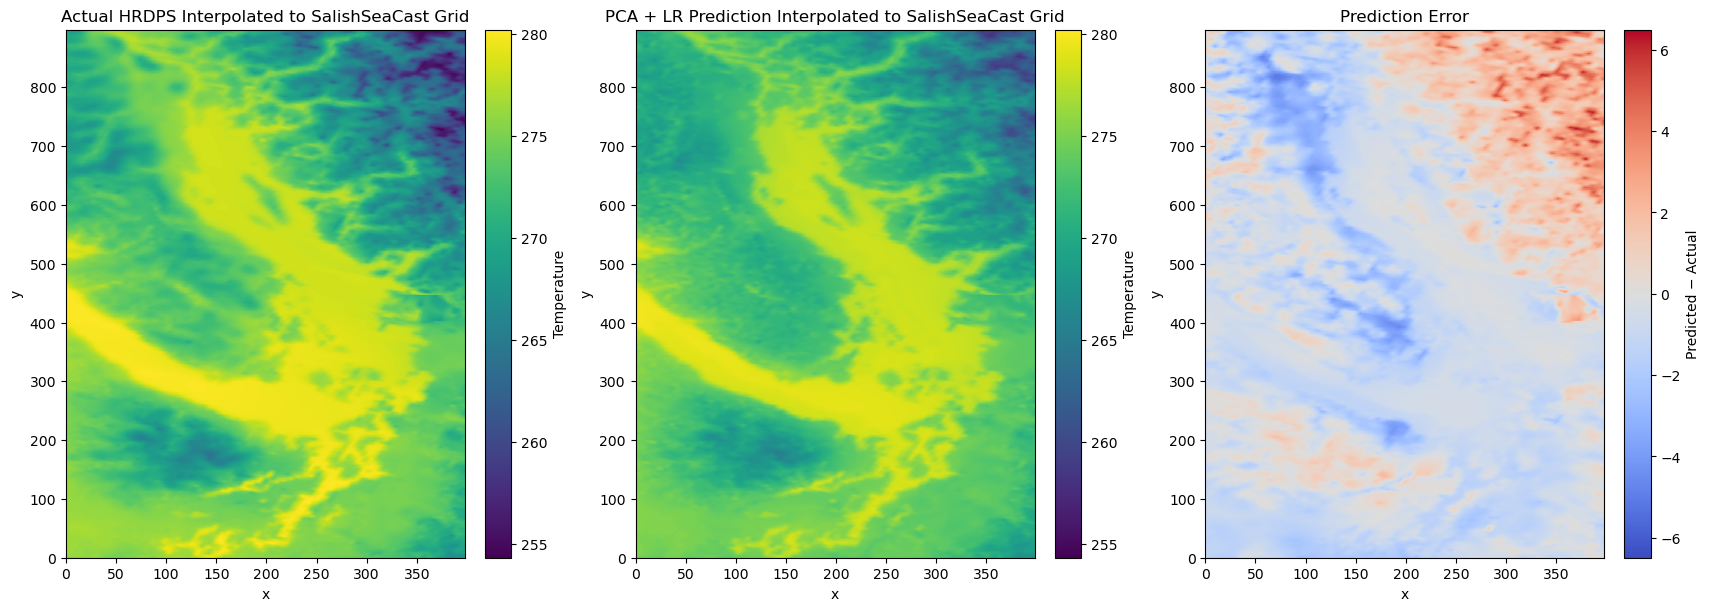

In [38]:
temp_vmin = min(np.nanmin(salishsea_actual),np.nanmin(salishsea_pred))
temp_vmax = max(np.nanmax(salishsea_actual),np.nanmax(salishsea_pred))
error = salishsea_pred - salishsea_actual
error_limit = max(abs(np.nanmin(error)),abs(np.nanmax(error)))
fig, axes = plt.subplots(1, 3, figsize=(17, 6), constrained_layout=True)
actual_plot = axes[0].pcolormesh(salishsea_actual,vmin=temp_vmin,vmax=temp_vmax)
axes[0].set_title("Actual HRDPS Interpolated to SalishSeaCast Grid")
axes[0].set_xlabel("x")
axes[0].set_ylabel("y")
fig.colorbar(actual_plot, ax=axes[0], label="Temperature")
pred_plot = axes[1].pcolormesh(salishsea_pred,vmin=temp_vmin,vmax=temp_vmax)
axes[1].set_title("PCA + LR Prediction Interpolated to SalishSeaCast Grid")
axes[1].set_xlabel("x")
axes[1].set_ylabel("y")
fig.colorbar(pred_plot, ax=axes[1], label="Temperature")
error_plot = axes[2].pcolormesh(error,vmin=-error_limit,vmax=error_limit,cmap="coolwarm")
axes[2].set_title("Prediction Error")
axes[2].set_xlabel("x")
axes[2].set_ylabel("y")
fig.colorbar(error_plot, ax=axes[2], label="Predicted − Actual")
plt.show()

In [39]:
val_times_datetime = pd.to_datetime(val_times)
summer_indices = np.where(val_times_datetime.month.isin([6, 7, 8]))[0]
print("Number of summer timestamps:", len(summer_indices))
print("First summer index:", summer_indices[0])
print("First summer timestamp:", val_times_datetime[summer_indices[0]])
print("Last summer index:", summer_indices[-1])
print("Last summer timestamp:", val_times_datetime[summer_indices[-1]])

Number of summer timestamps: 658
First summer index: 1208
First summer timestamp: 2008-06-01 00:00:00
Last summer index: 1865
Last summer timestamp: 2008-08-31 21:00:00


In [40]:
for index in summer_indices:
    print(index, val_times_datetime[index])

1208 2008-06-01 00:00:00
1209 2008-06-01 03:00:00
1210 2008-06-01 06:00:00
1211 2008-06-01 09:00:00
1212 2008-06-01 12:00:00
1213 2008-06-01 15:00:00
1214 2008-06-01 18:00:00
1215 2008-06-01 21:00:00
1216 2008-06-02 00:00:00
1217 2008-06-02 03:00:00
1218 2008-06-02 06:00:00
1219 2008-06-02 09:00:00
1220 2008-06-02 12:00:00
1221 2008-06-02 15:00:00
1222 2008-06-02 18:00:00
1223 2008-06-02 21:00:00
1224 2008-06-03 00:00:00
1225 2008-06-03 03:00:00
1226 2008-06-03 06:00:00
1227 2008-06-03 09:00:00
1228 2008-06-03 12:00:00
1229 2008-06-03 15:00:00
1230 2008-06-03 18:00:00
1231 2008-06-03 21:00:00
1232 2008-06-04 00:00:00
1233 2008-06-04 03:00:00
1234 2008-06-04 06:00:00
1235 2008-06-04 09:00:00
1236 2008-06-04 12:00:00
1237 2008-06-04 15:00:00
1238 2008-06-04 18:00:00
1239 2008-06-04 21:00:00
1240 2008-06-05 00:00:00
1241 2008-06-05 03:00:00
1242 2008-06-05 06:00:00
1243 2008-06-05 09:00:00
1244 2008-06-05 12:00:00
1245 2008-06-05 15:00:00
1246 2008-06-05 18:00:00
1247 2008-06-05 21:00:00


In [41]:
time_index = 1222
salishsea_actual = interpolate_hrdps_to_salishsea(X_hrdps_val_full[time_index],src,wgt)
salishsea_pred = interpolate_hrdps_to_salishsea(X_hrdps_val_pred_full[time_index],src,wgt)
print("Actual SalishSeaCast-grid field:", salishsea_actual.shape)
print("Predicted SalishSeaCast-grid field:", salishsea_pred.shape)
print("Timestamp:", val_times[time_index])

Actual SalishSeaCast-grid field: (898, 398)
Predicted SalishSeaCast-grid field: (898, 398)
Timestamp: 2008-06-02T18:00:00.000000000


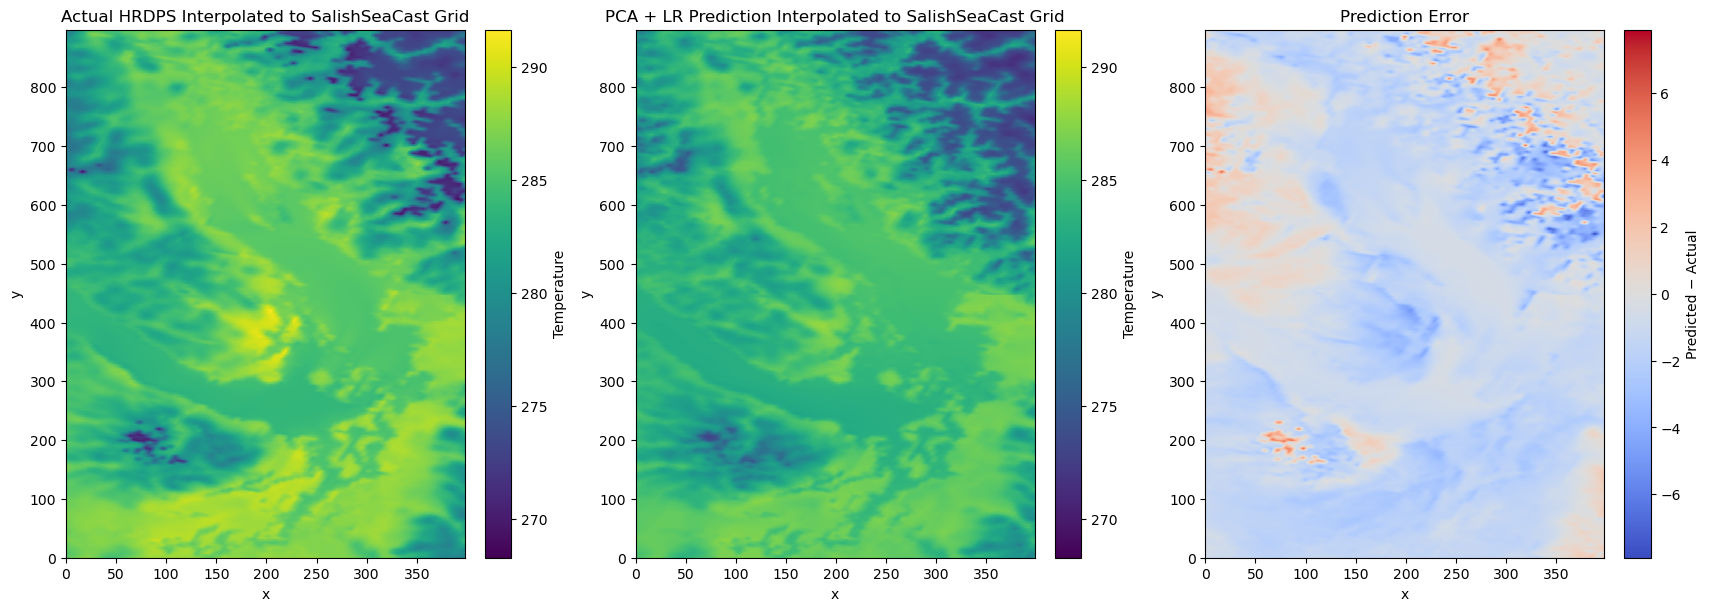

In [42]:
temp_vmin = min(np.nanmin(salishsea_actual),np.nanmin(salishsea_pred))
temp_vmax = max(np.nanmax(salishsea_actual),np.nanmax(salishsea_pred))
error = salishsea_pred - salishsea_actual
error_limit = max(abs(np.nanmin(error)),abs(np.nanmax(error)))
fig, axes = plt.subplots(1, 3, figsize=(17, 6), constrained_layout=True)
actual_plot = axes[0].pcolormesh(salishsea_actual,vmin=temp_vmin,vmax=temp_vmax)
axes[0].set_title("Actual HRDPS Interpolated to SalishSeaCast Grid")
axes[0].set_xlabel("x")
axes[0].set_ylabel("y")
fig.colorbar(actual_plot, ax=axes[0], label="Temperature")
pred_plot = axes[1].pcolormesh(salishsea_pred,vmin=temp_vmin,vmax=temp_vmax)
axes[1].set_title("PCA + LR Prediction Interpolated to SalishSeaCast Grid")
axes[1].set_xlabel("x")
axes[1].set_ylabel("y")
fig.colorbar(pred_plot, ax=axes[1], label="Temperature")
error_plot = axes[2].pcolormesh(error,vmin=-error_limit,vmax=error_limit,cmap="coolwarm")
axes[2].set_title("Prediction Error")
axes[2].set_xlabel("x")
axes[2].set_ylabel("y")
fig.colorbar(error_plot, ax=axes[2], label="Predicted − Actual")
plt.show()

In [43]:
time_index = 1380
salishsea_actual = interpolate_hrdps_to_salishsea(X_hrdps_val_full[time_index],src,wgt)
salishsea_pred = interpolate_hrdps_to_salishsea(X_hrdps_val_pred_full[time_index],src,wgt)
print("Actual SalishSeaCast-grid field:", salishsea_actual.shape)
print("Predicted SalishSeaCast-grid field:", salishsea_pred.shape)
print("Timestamp:", val_times[time_index])

Actual SalishSeaCast-grid field: (898, 398)
Predicted SalishSeaCast-grid field: (898, 398)
Timestamp: 2008-06-22T12:00:00.000000000


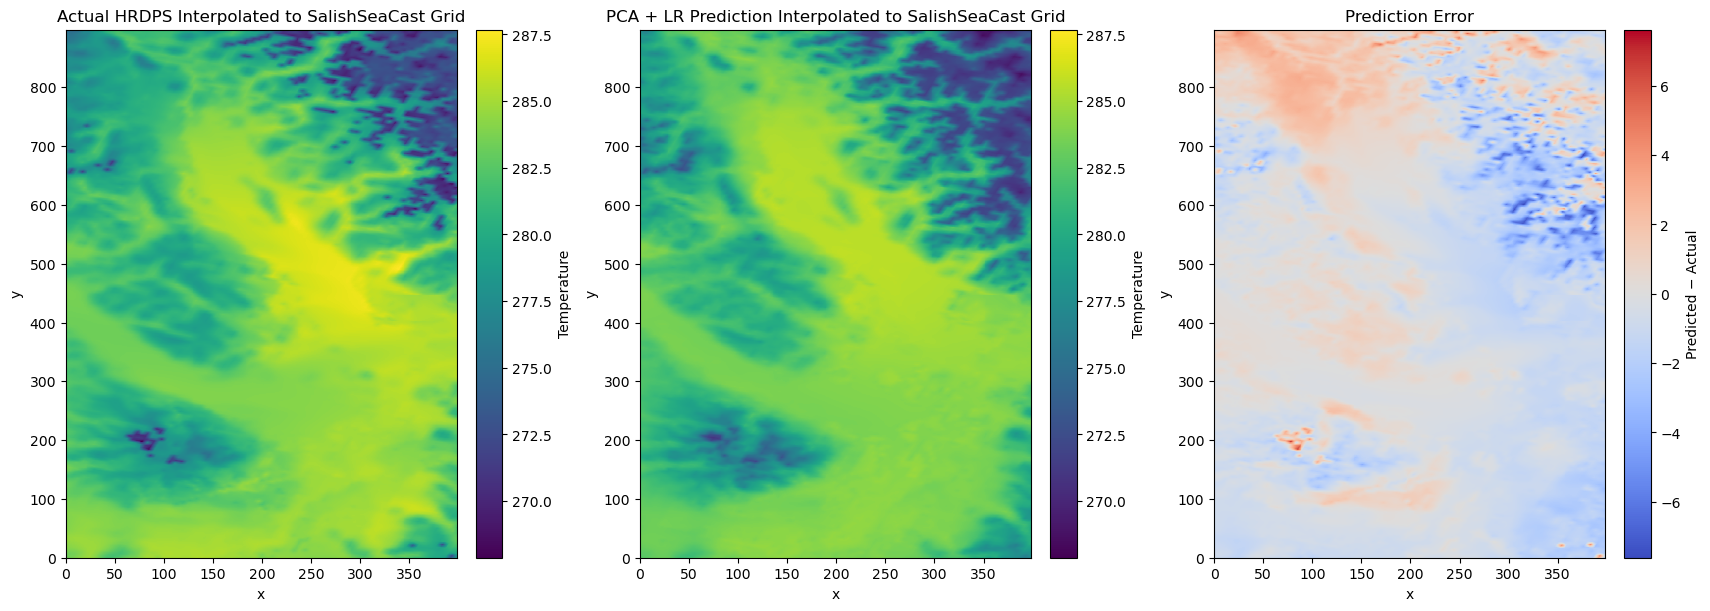

In [44]:
temp_vmin = min(np.nanmin(salishsea_actual),np.nanmin(salishsea_pred))
temp_vmax = max(np.nanmax(salishsea_actual),np.nanmax(salishsea_pred))
error = salishsea_pred - salishsea_actual
error_limit = max(abs(np.nanmin(error)),abs(np.nanmax(error)))
fig, axes = plt.subplots(1, 3, figsize=(17, 6), constrained_layout=True)
actual_plot = axes[0].pcolormesh(salishsea_actual,vmin=temp_vmin,vmax=temp_vmax)
axes[0].set_title("Actual HRDPS Interpolated to SalishSeaCast Grid")
axes[0].set_xlabel("x")
axes[0].set_ylabel("y")
fig.colorbar(actual_plot, ax=axes[0], label="Temperature")
pred_plot = axes[1].pcolormesh(salishsea_pred,vmin=temp_vmin,vmax=temp_vmax)
axes[1].set_title("PCA + LR Prediction Interpolated to SalishSeaCast Grid")
axes[1].set_xlabel("x")
axes[1].set_ylabel("y")
fig.colorbar(pred_plot, ax=axes[1], label="Temperature")
error_plot = axes[2].pcolormesh(error,vmin=-error_limit,vmax=error_limit,cmap="coolwarm")
axes[2].set_title("Prediction Error")
axes[2].set_xlabel("x")
axes[2].set_ylabel("y")
fig.colorbar(error_plot, ax=axes[2], label="Predicted − Actual")
plt.show()